In [3]:
import openml
dataset = openml.datasets.get_dataset(46880)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)


print(dataset)
print(f"data shape: {X.shape}")
print(f"name features: {y.nunique()}")
X.head()

OpenML Dataset
Name.........: air-quality-and-pollution-assessment
Version......: 2
Format.......: arff
Upload Date..: 2025-04-14 14:41:44
Licence......: Kaggle, Apache 2.0
Download URL.: https://openml.org/data/v1/download/22124444/air-quality-and-pollution-assessment.arff
OpenML URL...: https://www.openml.org/d/46880
# of features: None
data shape: (5000, 9)
name features: 4


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303


In [4]:
print(openml.__file__)

/home/franio/Desktop/Deep_Learning_Labs/venv/lib/python3.11/site-packages/openml/__init__.py


In [5]:
print(dataset.description)

Environmental Metrics and Demographic Insights for Predicting Air Quality


About Dataset
This dataset focuses on air quality assessment across various regions. The dataset contains 5000 samples and captures critical environmental and demographic factors that influence pollution levels.

Key Features:

Temperature (C): Average temperature of the region.
Humidity (percentage): Relative humidity recorded in the region.
PM2.5 Concentration (ug_per_m3): Fine particulate matter levels.
PM10 Concentration (ug_per_m3): Coarse particulate matter levels.
NO2 Concentration (ppb): Nitrogen dioxide levels.
SO2 Concentration (ppb): Sulfur dioxide levels.
CO Concentration (ppm): Carbon monoxide levels.
Proximity to Industrial Areas (km): Distance to the nearest industrial zone.
Population Density (people/km2): Number of people per square kilometer in the region.
Target Variable: Air Quality Levels

Good: Clean air with low pollution levels.
Moderate: Acceptable air quality but with some pollutants p

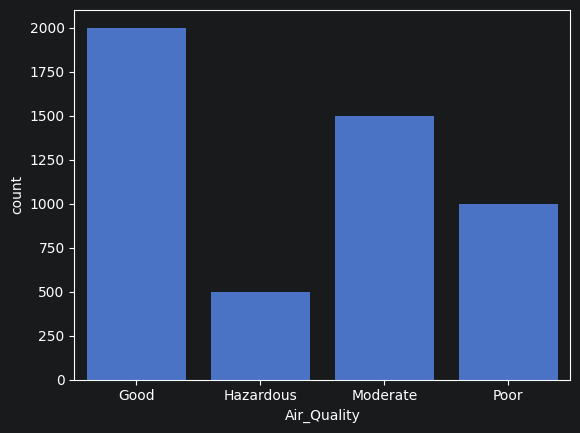

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = y.value_counts()

sns.barplot(counts)
plt.show()

# Check for Nans

## Features

In [7]:
na_count = X.isna().sum()

na_count

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
dtype: int64

## Classes

In [8]:
y_na_count = y.isna().sum()

y_na_count

0

No Nans, data is clean.

# TrainVal and Test data split

TrainVal sets consist 4000 samples
Test sets consist 1000 samples


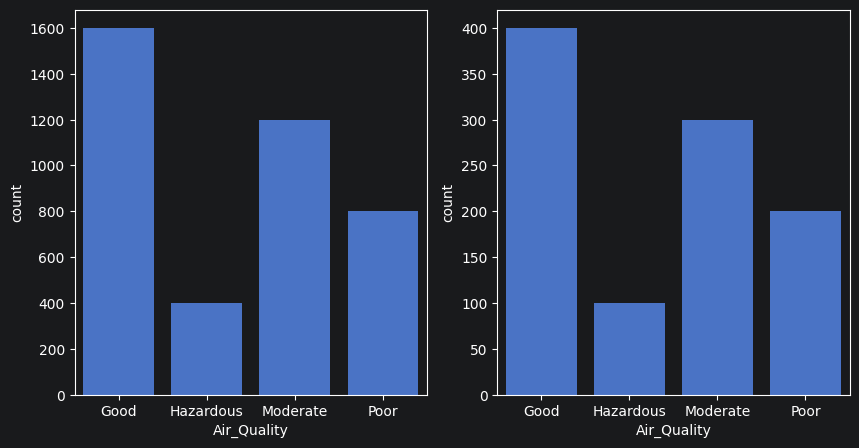

In [9]:
from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

trainval_count = y_trainval.value_counts()
test_count = y_test.value_counts()


print(f'TrainVal sets consist {len(y_trainval)} samples')
print(f'Test sets consist {len(y_test)} samples')

# Plots
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax = ax.flatten()

sns.barplot(trainval_count, ax=ax[0])
sns.barplot(test_count, ax=ax[1])
plt.show()


# Saving to csv

In [10]:
import os
import pandas as pd

os.makedirs('Data', exist_ok=True)


trainVal_data = pd.concat([X_trainval, y_trainval], axis=1)
path = os.path.join('Data', "trainVal.csv")
trainVal_data.to_csv(path, index=False)

testData = pd.concat([X_test, y_test], axis=1)
path = os.path.join('Data', "test.csv")
testData.to_csv(path, index=False)